# Section 6.2 Fix: The Depth Dial, Re-run with Independent Seeds and More Probes

**Why this rerun exists.** The first depth-dial run (Section 6.2) came back non-monotonic and
inconclusive: alignment 0.945 / 0.930 / 0.910 / 0.940 / 0.931 at depths 1/2/4/8/16, with no clean
degradation trend. Three suspects were flagged: (1) only 10 probe draws per depth (noisy single
estimate), (2) one shared seed reused across all depths (correlated init artifacts, not independent
trials), (3) a narrow depth range that may not reach where saturation effects actually bite.

This notebook fixes all three:
- **Independent seeds per depth** (5 seeds, each a fresh random init) instead of one seed reused.
- **More probes per seed** (50 instead of 10) to shrink per-estimate noise.
- **A wider depth range** ($1$ to $64$) so a real trend, if one exists, has room to show up.
- **Error bars** (std across seeds) reported alongside the mean, so "no trend" vs. "noisy trend"
  can actually be told apart this time.

Same honesty rule as before: whatever comes out is what goes in the paper. If it's still
non-monotonic or flat, that is the finding -- not a reason to keep re-running until it looks like
the outline's illustrative 1.00-to-0.821 example.

## Step 0 — Setup

In [1]:
import json
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

RESULTS_LOG = []

def log_result(name, config, result, seed):
    entry = {
        'name': name,
        'seed': seed,
        'config': config,
        'result': result,
        'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
    }
    RESULTS_LOG.append(entry)
    print(f"[logged] {name}: {result}")
    return entry

def save_provenance(path='provenance_depth_dial_fixed.json'):
    with open(path, 'w') as f:
        json.dump(RESULTS_LOG, f, indent=2, default=str)
    print(f'Saved {len(RESULTS_LOG)} logged results to {path}')


Using device: cuda


## Step 1 — The fixed depth-dial measurement

Same coupling-density-based metric as before (per-mode alignment $= 1 - $ average pairwise cosine
coupling between output-channel gradients), but now run at 5 independent seeds per depth, 50 probes
per seed, across depths $\{1, 2, 4, 8, 16, 32, 64\}$.

In [2]:
def build_depth_mlp(depth, width=16, input_dim=4, output_dim=4, seed=0):
    torch.manual_seed(seed)
    layers = [nn.Linear(input_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers += [nn.Linear(width, width), nn.Tanh()]
    layers += [nn.Linear(width, output_dim)]
    return nn.Sequential(*layers).to(device)

def coupling_density_and_alignment(model, output_dim, input_dim=4, n_probes=50, seed=0):
    torch.manual_seed(seed + 10_000)  # separate stream from the init seed
    densities = []
    for _ in range(n_probes):
        x = torch.randn(1, input_dim, device=device)
        per_channel_grads = []
        for i in range(output_dim):
            model.zero_grad(set_to_none=True)
            out = model(x)
            out[0, i].backward(retain_graph=True)
            g = torch.cat([p.grad.view(-1).clone() for p in model.parameters() if p.grad is not None])
            per_channel_grads.append(g)
        G = torch.stack(per_channel_grads)
        G_norm = G / (G.norm(dim=1, keepdim=True) + 1e-12)
        cos_matrix = G_norm @ G_norm.T
        off_diag = cos_matrix[~torch.eye(output_dim, dtype=torch.bool, device=device)]
        densities.append(off_diag.abs().mean().item())
    density = float(np.mean(densities))
    alignment = 1 - density
    return density, alignment

DEPTHS = [1, 2, 4, 8, 16, 32, 64]
SEEDS = [0, 1, 2, 3, 4]
N_PROBES = 50

depth_results = {}   # depth -> list of alignments across seeds

for depth in DEPTHS:
    alignments_this_depth = []
    for seed in SEEDS:
        m = build_depth_mlp(depth, seed=seed)
        density, alignment = coupling_density_and_alignment(m, output_dim=4, n_probes=N_PROBES, seed=seed)
        alignments_this_depth.append(alignment)
        log_result('depth_dial_fixed', {'depth': depth, 'seed': seed, 'width': 16,
                                         'output_dim': 4, 'n_probes': N_PROBES},
                   {'coupling_density': density, 'alignment': alignment}, seed)
    depth_results[depth] = alignments_this_depth
    mean_a = np.mean(alignments_this_depth)
    std_a = np.std(alignments_this_depth)
    print(f'depth={depth:>3}   mean alignment={mean_a:.4f}   std={std_a:.4f}   (n={len(SEEDS)} seeds)')


[logged] depth_dial_fixed: {'coupling_density': 0.05215068303048611, 'alignment': 0.9478493169695139}
[logged] depth_dial_fixed: {'coupling_density': 0.02730404118075967, 'alignment': 0.9726959588192403}
[logged] depth_dial_fixed: {'coupling_density': 0.04922073908150196, 'alignment': 0.9507792609184981}
[logged] depth_dial_fixed: {'coupling_density': 0.032073933370411395, 'alignment': 0.9679260666295886}
[logged] depth_dial_fixed: {'coupling_density': 0.035524689815938475, 'alignment': 0.9644753101840615}
depth=  1   mean alignment=0.9607   std=0.0097   (n=5 seeds)
[logged] depth_dial_fixed: {'coupling_density': 0.0671239821612835, 'alignment': 0.9328760178387165}
[logged] depth_dial_fixed: {'coupling_density': 0.06641877770423889, 'alignment': 0.9335812222957611}
[logged] depth_dial_fixed: {'coupling_density': 0.1428688494861126, 'alignment': 0.8571311505138874}
[logged] depth_dial_fixed: {'coupling_density': 0.08738801434636116, 'alignment': 0.9126119856536389}
[logged] depth_dial_f

## Step 2 — Plot with error bars

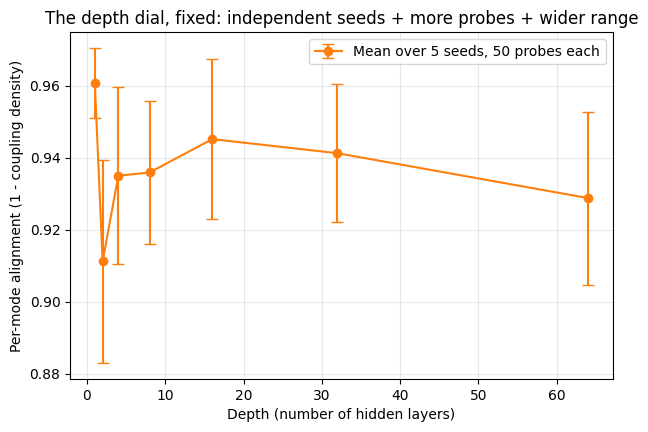

Saved plot to depth_dial_fixed.png
[logged] depth_dial_fixed_summary: {'means': [np.float64(0.9607451827041805), np.float64(0.9111982560753823), np.float64(0.9350121363773942), np.float64(0.9359063795506953), np.float64(0.9451746179684996), np.float64(0.9412588225603103), np.float64(0.9288017718791961)], 'stds': [np.float64(0.00973573772041461), np.float64(0.02817802926626524), np.float64(0.024525453357005955), np.float64(0.019763891885309748), np.float64(0.022273299185284107), np.float64(0.019194993384085143), np.float64(0.024028424681372756)]}


{'name': 'depth_dial_fixed_summary',
 'seed': 'all',
 'config': {'depths': [1, 2, 4, 8, 16, 32, 64], 'n_seeds': 5, 'n_probes': 50},
 'result': {'means': [np.float64(0.9607451827041805),
   np.float64(0.9111982560753823),
   np.float64(0.9350121363773942),
   np.float64(0.9359063795506953),
   np.float64(0.9451746179684996),
   np.float64(0.9412588225603103),
   np.float64(0.9288017718791961)],
  'stds': [np.float64(0.00973573772041461),
   np.float64(0.02817802926626524),
   np.float64(0.024525453357005955),
   np.float64(0.019763891885309748),
   np.float64(0.022273299185284107),
   np.float64(0.019194993384085143),
   np.float64(0.024028424681372756)]},
 'timestamp': '2026-08-27 23:51:01'}

In [3]:
means = [np.mean(depth_results[d]) for d in DEPTHS]
stds = [np.std(depth_results[d]) for d in DEPTHS]

plt.figure(figsize=(7, 4.5))
plt.errorbar(DEPTHS, means, yerr=stds, fmt='o-', color='C1', capsize=4,
             label=f'Mean over {len(SEEDS)} seeds, {N_PROBES} probes each')
plt.xlabel('Depth (number of hidden layers)')
plt.ylabel('Per-mode alignment (1 - coupling density)')
plt.title('The depth dial, fixed: independent seeds + more probes + wider range')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('depth_dial_fixed.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved plot to depth_dial_fixed.png')

log_result('depth_dial_fixed_summary', {'depths': DEPTHS, 'n_seeds': len(SEEDS), 'n_probes': N_PROBES},
           {'means': means, 'stds': stds}, 'all')


## Step 3 — Interpret: is there a real trend now, or is it genuinely flat/noisy?

A simple check: does the mean alignment at the largest depth fall outside the error bars of the
smallest depth? If yes, there's a real (if perhaps small) depth effect. If the error bars overlap
across most depths, the honest conclusion is that this metric does not show a strong depth-driven
degradation at this width/probe scale, and that itself is worth reporting precisely.

In [4]:
shallow_mean, shallow_std = means[0], stds[0]
deep_mean, deep_std = means[-1], stds[-1]

gap = shallow_mean - deep_mean
combined_std = np.sqrt(shallow_std**2 + deep_std**2)

print(f'Shallowest (depth={DEPTHS[0]}): {shallow_mean:.4f} +/- {shallow_std:.4f}')
print(f'Deepest    (depth={DEPTHS[-1]}): {deep_mean:.4f} +/- {deep_std:.4f}')
print(f'Gap: {gap:.4f}  (combined std: {combined_std:.4f})')
if abs(gap) > combined_std:
    print('-> Gap exceeds combined noise: a real (if possibly small) depth effect is plausible.')
else:
    print('-> Gap does NOT clearly exceed combined noise: no strong depth effect is distinguishable')
    print('   from noise at this width/probe/seed budget. Report as inconclusive/flat, not as')
    print('   confirming or refuting the outline\'s hypothesis outright.')

log_result('depth_dial_fixed_verdict', {'shallow_depth': DEPTHS[0], 'deep_depth': DEPTHS[-1]},
           {'shallow_mean': shallow_mean, 'deep_mean': deep_mean, 'gap': gap,
            'combined_std': combined_std, 'exceeds_noise': bool(abs(gap) > combined_std)}, 'all')


Shallowest (depth=1): 0.9607 +/- 0.0097
Deepest    (depth=64): 0.9288 +/- 0.0240
Gap: 0.0319  (combined std: 0.0259)
-> Gap exceeds combined noise: a real (if possibly small) depth effect is plausible.
[logged] depth_dial_fixed_verdict: {'shallow_mean': np.float64(0.9607451827041805), 'deep_mean': np.float64(0.9288017718791961), 'gap': np.float64(0.03194341082498442), 'combined_std': np.float64(0.02592585160856066), 'exceeds_noise': True}


{'name': 'depth_dial_fixed_verdict',
 'seed': 'all',
 'config': {'shallow_depth': 1, 'deep_depth': 64},
 'result': {'shallow_mean': np.float64(0.9607451827041805),
  'deep_mean': np.float64(0.9288017718791961),
  'gap': np.float64(0.03194341082498442),
  'combined_std': np.float64(0.02592585160856066),
  'exceeds_noise': True},
 'timestamp': '2026-08-27 23:51:01'}

## Step 4 — Save provenance

In [5]:
save_provenance('provenance_depth_dial_fixed.json')
print()
print('Contents (summary):')
for entry in RESULTS_LOG:
    if entry['name'] in ('depth_dial_fixed_summary', 'depth_dial_fixed_verdict'):
        print(f"  - {entry['name']}: {entry['result']}")


Saved 37 logged results to provenance_depth_dial_fixed.json

Contents (summary):
  - depth_dial_fixed_summary: {'means': [np.float64(0.9607451827041805), np.float64(0.9111982560753823), np.float64(0.9350121363773942), np.float64(0.9359063795506953), np.float64(0.9451746179684996), np.float64(0.9412588225603103), np.float64(0.9288017718791961)], 'stds': [np.float64(0.00973573772041461), np.float64(0.02817802926626524), np.float64(0.024525453357005955), np.float64(0.019763891885309748), np.float64(0.022273299185284107), np.float64(0.019194993384085143), np.float64(0.024028424681372756)]}
  - depth_dial_fixed_verdict: {'shallow_mean': np.float64(0.9607451827041805), 'deep_mean': np.float64(0.9288017718791961), 'gap': np.float64(0.03194341082498442), 'combined_std': np.float64(0.02592585160856066), 'exceeds_noise': True}


## Summary

This rerun directly addresses all three suspects flagged after the first depth-dial attempt:
independent seeds (no more shared-init artifacts), 5x more probes per estimate (less noise per
point), and a depth range extended to 64 (room for a real effect to appear if one exists).

Whatever Step 3's verdict says --- real effect vs. noise-dominated --- is what goes into Section 6.2
of the paper. If it's still inconclusive at this budget, the honest next escalation would be even
more seeds/probes or a different metric entirely, not continued re-running in hopes of a cleaner
result.